# datalake NYC Taxi × Météo

## Contexte

La NYC Taxi & Limousine Commission (TLC) publie chaque mois, depuis 2009, l'intégralité des courses de taxis et de véhicules de transport avec chauffeur effectuées à New York. Ce jeu de données est massif et a etait modifier plusieur fois a travers les années 


---
## Les quatre types de véhicules

| Type | Début de publication | Remarque |
|---|---|---|
| **Yellow taxi** | Janvier 2009 | Le plus ancien, le plus documenté |
| **Green taxi** | Août 2013 | Créé pour desservir les zones hors Manhattan central |
| **FHV** (For-Hire Vehicle) | 2015 | Véhicules privé, ensuite uniquement Véhicules de tourisme/limousines |
| **FHVHV** (High Volume For-Hire Vehicle) | Février 2019 | Créé par la loi locale 149 (2018) pour les plateformes dispatchant plus de 10 000 courses/jour (Uber et Lyft) |

**Point d'attention :** depuis 2019 FHV capte seulement les courses des plateformes qui dépassent le seuil des 10 000 courses/jour, tandis que FHV continue de couvrir le reste des bases de VTC/limousines. FHV est structurellement beaucoup plus pauvre : il ne contient ni tarif, ni distance (sub based service)


## Localisation des prises en charge / dépose

Jusqu'en juin 2016, les fichiers contiennent des **coordonnées GPS brutes** (latitude/longitude) pour la prise en charge et la dépose. À partir de juillet 2016, la TLC ne publie plus de coordonnées GPS : chaque course référence à la place un **identifiant de zone** (`LocationID`), qui renvoie vers une table de référence publiée séparément par la TLC (zones, arrondissements, géométries).

## Colonnes apparues au fil du temps

Plusieurs colonnes tarifaires sont apparues progressivement dans le schéma (elles n'existaient tout simplement pas dans les fichiers plus anciens) :

- des frais aéroport
- un supplément d'amélioration du service, introduit en 2015 ;
- un supplément de congestion (congestion pricing), introduit en 2019 ;
- un nouveau supplément lié à la zone de tarification de congestion de Manhattan (« CBD »), en vigueur depuis le 5 janvier 2025.

## Fréquence de publication

Les données sont publiées mensuellement, avec un délai d'environ deux mois (les données de janvier sortent typiquement fin février/début mars).

---
## Solution — Environnement et dépendances

Le pipeline tourne en **Spark local** sur ce poste ; la hiérarchie de répertoires imite exactement celle d'un HDFS :
remplacer les chemins `datalake/...` par `hdfs://<namenode>/datalake/...` ne change rien au code.

Dépendances installées :

```
pip install pyspark pyarrow pandas matplotlib seaborn requests shapely pyproj pyshp
```

Sous Windows, PySpark exige `winutils.exe` + `hadoop.dll` (HADOOP_HOME). Le référentiel des zones TLC
(shapefile EPSG:2263) est reprojecté en WGS84 via `pyproj`, et le géocodage GPS→zone utilise `shapely`.

In [1]:
import os, sys, json, shutil, tempfile, zipfile
from pathlib import Path
from datetime import date, datetime

BASE      = Path.cwd().resolve()
DATALAKE  = BASE / "datalake"
BRONZE    = DATALAKE / "bronze"
SILVER    = DATALAKE / "silver"
GOLD_DIR  = DATALAKE / "gold"
REF_DIR   = DATALAKE / "ref"

# --- PySpark sous Windows : winutils obligatoire même pour un filesystem local ---
HADOOP_HOME = Path(r"C:\hadoop")
if HADOOP_HOME.exists():
    os.environ["HADOOP_HOME"] = str(HADOOP_HOME)
    os.environ["PATH"] = str(HADOOP_HOME / "bin") + os.pathsep + os.environ["PATH"]
os.environ.setdefault("PYSPARK_PYTHON", sys.executable)
os.environ.setdefault("PYSPARK_DRIVER_PYTHON", sys.executable)

TLC_TRIP_DATA = "https://d37ci6vzurychx.cloudfront.net/trip-data"
TLC_ZONES_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"
OPEN_METEO_ARCHIVE = "https://archive-api.open-meteo.com/v1/archive"

VEHICLES = {  # type -> (premier mois publié, préfixe de fichier TLC)
    "yellow": ("2009-01", "yellow_tripdata"),
    "green":  ("2013-08", "green_tripdata"),
    "fhv":    ("2015-01", "fhv_tripdata"),
    "fhvhv":  ("2019-02", "fhvhv_tripdata"),
}

def bronze_taxi_path(vtype, year, month):
    """datalake/bronze/taxi/vtype=yellow/year=2009/month=01/data.parquet"""
    return BRONZE / "taxi" / f"vtype={vtype}" / f"year={year}" / f"month={month:02d}" / "data.parquet"

def bronze_weather_path(year):
    """datalake/bronze/weather/year=2009/data.json"""
    return BRONZE / "weather" / f"year={year}" / "data.json"

def month_iter(y0, m0, y1, m1):
    y, m = y0, m0
    while (y, m) <= (y1, m1):
        yield y, m
        m += 1
        if m == 13:
            y, m = y + 1, 1

print("Datalake :", DATALAKE)

Datalake : C:\Users\soufp\Desktop\Data\datalake


---
# Bronze : ingestion et organisation dans HDFS

1. **Concevez une convention de nommage des chemins** dans HDFS pour organiser les données brutes. On ne vous dit pas quelle convention utiliser — mais votre convention doit permettre de répondre facilement, sans avoir à lire le contenu des fichiers, aux questions suivantes :
   - Quels types de véhicules ai-je déjà ingérés ?
   - Pour quelle période (année/mois) ai-je des données pour un type donné ?
   - Est-ce qu'un mois précis d'un type précis a déjà été ingéré (pour ne pas le re-télécharger) ?

2. **Écrivez le script d'ingestion** qui télécharge les fichiers et les dépose dans HDFS. Points critique :
   - il doit pouvoir être interrompu et relancé sans tout retélécharger ;
   - il doit gérer le fait que chaque type de véhicule n'existe pas depuis la même date;

3. **Ingérez aussi la météo.** source de données météo historiques horaires pour New York (Open-Meteo ou de la NOAA) le type de persitence pour les données meteroloique devrait etre logique par rapport a la source utilisé (API / parquet).


---
## Solution — Convention de nommage Bronze

Hiérarchie retenue (valable telle quelle sur HDFS, S3 ou en local) :

```
datalake/
└── bronze/
    ├── taxi/vtype=<type>/year=<YYYY>/month=<MM>/data.parquet
    └── weather/year=<YYYY>/data.json
```

Elle répond aux trois questions **sans lire le contenu des fichiers** :

| Question | Réponse |
|---|---|
| Quels types ai-je déjà ingérés ? | `ls bronze/taxi` → sous-répertoires `vtype=` |
| Quelle période pour un type donné ? | sous-répertoires `year=/month=` de chaque `vtype=` |
| Ce mois précis est-il déjà ingéré ? | le fichier `data.parquet` existe-t-il à son chemin canonique |

L'ingestion est **idempotente** (si le fichier cible existe → skip), **repreneur** (écriture atomique
via `.part` puis renommage : une interruption ne laisse jamais un fichier corrompu) et gère les dates
de début différentes par type via le dictionnaire `VEHICLES`.

In [2]:
import requests, re

PUBLICATION_LAG_MONTHS = 2   # délai de publication annoncé par la TLC
INGEST_FULL_HISTORY = False  # True => télécharge TOUT l'historique TLC (centaines de Go !)
LOCAL_MIRROR = BASE          # fichiers déjà présents localement : <mirror>/<type>/<type>/<yyyy>/<mm>/

def last_published_month(today=None):
    """Dernier mois réellement publié, délai de publication déduit."""
    today = today or date.today()
    total = today.year * 12 + today.month - 1 - PUBLICATION_LAG_MONTHS - 1
    return divmod(total, 12)

def ingest_month(vtype, year, month):
    """Ingère un mois d'un type. Retourne l'action effectuée (idempotent)."""
    dst = bronze_taxi_path(vtype, year, month)
    if dst.exists():
        return "déjà ingéré"
    prefix = VEHICLES[vtype][1]
    dst.parent.mkdir(parents=True, exist_ok=True)
    tmp = dst.parent / (dst.name + ".part")

    local = next((p for p in [
            LOCAL_MIRROR / vtype / str(year) / f"{month:02d}" / f"{prefix}_{year}-{month:02d}.parquet",
            LOCAL_MIRROR / vtype / vtype / str(year) / f"{month:02d}" / f"{prefix}_{year}-{month:02d}.parquet",
        ] if p.exists()), None)
    if local is not None:
        shutil.copyfile(local, tmp)
        action = "copié (miroir local)"
    else:
        url = f"{TLC_TRIP_DATA}/{prefix}_{year}-{month:02d}.parquet"
        with requests.get(url, stream=True, timeout=900) as r:
            r.raise_for_status()
            with open(tmp, "wb") as fh:
                shutil.copyfileobj(r.raw, fh, length=8 * 1024 * 1024)
        action = "téléchargé"
    tmp.replace(dst)  # renommage atomique
    return action

def plan_ingestion(full_history=False):
    """Liste (vtype, année, mois) à ingérer : tout l'historique publié, ou le miroir local."""
    ey, em = last_published_month()
    plan = []
    if full_history:
        for vt, (start, _) in VEHICLES.items():
            sy, sm = map(int, start.split("-"))
            plan += [(vt, y, m) for y, m in month_iter(sy, sm, ey, em)]
    else:
        # ne traite que ce qui existe déjà sur disque : scan par préfixe de fichier TLC,
        # quel que soit l'arborescence locale ; année/mois extraits du nom du fichier.
        pat = re.compile(r"(\d{4})-(\d{2})\.parquet$")
        for vt in VEHICLES:
            prefix = VEHICLES[vt][1]
            for p in sorted(BASE.rglob(f"{prefix}_*.parquet")):
                if str(p).startswith(str(DATALAKE)):
                    continue                      # ne pas ré-ingérer notre propre bronze
                m = pat.search(p.name)
                if m:
                    plan.append((vt, int(m.group(1)), int(m.group(2))))
    return sorted(set(plan))

plan = plan_ingestion(INGEST_FULL_HISTORY)
print(f"{len(plan)} fichier(s) à ingérer\n")

stats = {}
for vt, y, m in plan:
    action = ingest_month(vt, y, m)
    stats.setdefault(vt, []).append((y, m))
    print(f"  {action:<20} | {vt:<6} {y}-{m:02d}")

print()
for vt, lst in stats.items():
    print(f"{vt}: {len(lst)} mois ingérés "
          f"({lst[0][0]}-{lst[0][1]:02d} → {lst[-1][0]}-{lst[-1][1]:02d})")

12 fichier(s) à ingérer

  déjà ingéré          | yellow 2009-01
  déjà ingéré          | yellow 2009-02
  déjà ingéré          | yellow 2009-03
  déjà ingéré          | yellow 2009-04
  déjà ingéré          | yellow 2009-05
  déjà ingéré          | yellow 2009-06
  déjà ingéré          | yellow 2009-07
  déjà ingéré          | yellow 2009-08
  déjà ingéré          | yellow 2009-09
  déjà ingéré          | yellow 2009-10
  déjà ingéré          | yellow 2009-11
  déjà ingéré          | yellow 2009-12

yellow: 12 mois ingérés (2009-01 → 2009-12)


In [3]:
# La source météo est une API => on persiste la réponse BRUTE (JSON), cohérent avec la source.
# (Si la source avait été des fichiers parquets, on les aurait stockés tels quels.)
HOURLY_VARS = ["temperature_2m", "relative_humidity_2m", "precipitation",
               "rain", "snowfall", "wind_speed_10m", "weather_code"]
NYC_POINT = {"latitude": 40.7128, "longitude": -74.0060, "timezone": "America/New_York"}  # Lower Manhattan

def fetch_weather_year(year):
    dst = bronze_weather_path(year)
    if dst.exists():
        return "déjà ingéré"
    params = dict(NYC_POINT,
                  start_date=f"{year}-01-01",
                  end_date=f"{year}-12-31",
                  hourly=",".join(HOURLY_VARS))
    r = requests.get(OPEN_METEO_ARCHIVE, params=params, timeout=300)
    r.raise_for_status()
    dst.parent.mkdir(parents=True, exist_ok=True)
    tmp = dst.parent / (dst.name + ".part")
    tmp.write_text(json.dumps(r.json()), encoding="utf-8")
    tmp.replace(dst)
    return "ingéré"

years = sorted({y for _, y, _ in plan})
for y in years:
    print(y, "->", fetch_weather_year(y))

2009 -> déjà ingéré


---
# Silver : nettoyage, réconciliation et modélisation


## Choisissez votre système de stockage



### Réconcilier les deux systèmes de localisation

Rappel : coordonnées GPS brutes avant juillet 2016, identifiants de zone après. Vous devez faire en sorte que toutes vos courses, quelle que soit leur date, puissent être rattachées à une même notion de zone/arrondissement.


### Gérer les colonnes apparues progressivement

Rappel : plusieurs suppléments tarifaires n'existaient pas dans les fichiers les plus anciens. Une valeur manquante *avant* l'introduction d'un supplément et une valeur de 0 *après* son introduction ne signifient pas la même chose. Assurez-vous que votre pipeline ne confond pas les deux pour bien les prendre en consideration plus tard au niveau des insights



votre modèle silver doit permettre de répondre, sans retourner aux fichiers bronze, à des questions comme : 

*combien de courses par type de véhicule et par mois*, 
*quelle est la zone de prise en charge la plus fréquente*, 
*quelle est la météo au moment d'une course donnée*. 

### Choix du système de stockage

**Parquet partitionné façon Hive + tables Spark SQL**, sans couche transactionnelle (Delta/Iceberg) :
une dépendance de moins sur ce poste, et le besoin — analyses analytiques batch sans mises à jour — ne
l'exige pas. Migrer vers Delta ne changerait que `.write.format("delta")`.

Layout : `silver/trips/vtype=…/year=…/month=…` (partition pruning), `silver/weather_hourly/year=…`,
référentiels dans `silver/ref/`.

### Modélisation silver

| Table | Granularité | Contenu clé |
|---|---|---|
| `silver/trips` | 1 ligne = 1 course | horodatages typés, `pickup_location_id` / `dropoff_location_id` **unifiés GPS→zone**, montants canoniques, booléens `<colonne>_applicable` |
| `silver/zones` | 1 ligne = zone TLC | `location_id`, borough, nom, centroïde WGS84 |
| `silver/ref/grid_zones` | maille 0.001° (~110 m) | correspondance maille → zone, pour géocoder le GPS brut **sans UDF** |
| `silver/weather_hourly` | 1 ligne = heure NYC | température, précipitations, vent… |

**Réconciliation des deux systèmes de localisation** — avant juillet 2016 : coordonnées GPS arrondies
sur la grille, jointure broadcast vers la zone contenant la maille ; après : `LocationID` publié par la
TLC. Les deux chemins aboutissent à la même clé `*_location_id`. Le GPS hors grille (outliers du type
latitude 935 !) donne une zone NULL : la ligne est conservée mais traçable.

**Colonnes apparues progressivement** — chaque montant absent d'un vieux fichier reste **NULL**
(jamais converti en 0), accompagné d'un booléen `<colonne>_applicable` calculé depuis la date de prise
en charge et la date réglementaire d'introduction. On distingue donc :
* NULL + non applicable → « le supplément n'existait pas encore » ;
* NULL ou 0 + applicable → « il existait mais n'a pas été facturé sur cette course ».

Ces tables suffisent à répondre sans relire le bronze : courses/mois/type (`GROUP BY vtype, year,
month`), zone la plus fréquente (jointure `zones`), météo d'une course (jointure horaire `weather_hourly`).

In [4]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F, types as T

spark_tmp = Path(tempfile.gettempdir()) / "opencode" / "spark_tmp"
spark_tmp.mkdir(parents=True, exist_ok=True)

spark = (SparkSession.builder
         .master("local[6]")
         .appName("datalake-taxi-nyc")
         .config("spark.driver.memory", "2560m")
         .config("spark.local.dir", str(spark_tmp))
         .config("spark.sql.shuffle.partitions", "24")
         .config("spark.ui.enabled", "false")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark", spark.version)

C:\Users\soufp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Spark 4.2.0


In [5]:
# Référentiel zones : shapefile TLC (EPSG:2263, pieds US) -> WGS84 -> grille 0.001°
import numpy as np
import pandas as pd
import shapefile
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union
from shapely import STRtree, contains_xy
from pyproj import Transformer

REF_DIR.mkdir(parents=True, exist_ok=True)
shp_root = REF_DIR / "taxi_zones"
shp_file = next(shp_root.rglob("taxi_zones.shp"), None) if shp_root.exists() else None
if shp_file is None:
    zip_dst = REF_DIR / "taxi_zones.zip"
    if not zip_dst.exists():
        zip_dst.write_bytes(requests.get(TLC_ZONES_URL, timeout=120).content)
    with zipfile.ZipFile(zip_dst) as z:
        z.extractall(shp_root)
    shp_file = next(shp_root.rglob("taxi_zones.shp"))

sf = shapefile.Reader(str(shp_file))
field_names = [f[0] for f in sf.fields[1:]]           # saute DeletionFlag
to_wgs84 = Transformer.from_crs("EPSG:2263", "EPSG:4326", always_xy=True)

rings, ring_locid, by_locid = [], [], {}
for i, shp in enumerate(sf.shapes()):
    rec = dict(zip(field_names, sf.record(i)))
    lid = int(rec["LocationID"])
    parts = list(shp.parts) + [len(shp.points)]
    polys = []
    for a, b in zip(parts[:-1], parts[1:]):
        ring_pts = shp.points[a:b]
        if len(ring_pts) < 4:
            continue
        poly = Polygon([to_wgs84.transform(x, y) for x, y in ring_pts])
        if not poly.is_valid:
            poly = poly.buffer(0)
        rings.append(poly)
        ring_locid.append(lid)
        polys.append(poly)
    centroid = unary_union(polys).centroid if polys else None
    if centroid is not None:
        by_locid[lid] = (rec["borough"], rec["zone"], centroid.x, centroid.y)

zones = pd.DataFrame(
    [(lid, b, z, cx, cy) for lid, (b, z, cx, cy) in sorted(by_locid.items())],
    columns=["location_id", "borough", "zone_name", "center_lon", "center_lat"])

tree = STRtree(rings)
STEP = 1000                                            # 0.001° ≈ 110 m
bounds = np.array([r.bounds for r in rings])
lon_min, lat_min = bounds[:, [0, 1]].min(axis=0) - 0.002
lon_max, lat_max = bounds[:, [2, 3]].max(axis=0) + 0.002
gx, gy = np.meshgrid(np.arange(round(lon_min * STEP), round(lon_max * STEP) + 1),
                     np.arange(round(lat_min * STEP), round(lat_max * STEP) + 1))
lon_k, lat_k = gx.ravel(), gy.ravel()
clon, clat = lon_k / STEP, lat_k / STEP

pairs = tree.query([Point(x, y) for x, y in zip(clon, clat)])
owner = np.full(len(lon_k), -1, dtype=np.int64)
for pi, ri in zip(*pairs):
    if owner[pi] == -1 and contains_xy(rings[ri], clon[pi], clat[pi]):
        owner[pi] = ring_locid[ri]
mask = owner >= 0

grid = pd.DataFrame({"lon_key": lon_k[mask], "lat_key": lat_k[mask],
                     "location_id": owner[mask].astype(int)})
grid = grid.merge(zones[["location_id", "borough"]], on="location_id", how="left")

(SILVER / "ref").mkdir(parents=True, exist_ok=True)
zones.to_parquet(SILVER / "ref" / "zones.parquet", index=False)
grid.to_parquet(SILVER / "ref" / "grid_zones.parquet", index=False)

print(f"{len(zones)} zones | {len(grid)} mailles assignées "
      f"({len(grid) / len(lon_k):.1%} de la bbox NYC)")
print(zones.groupby('borough').size().to_string())

263 zones | 84494 mailles assignées (35.4% de la bbox NYC)
borough
Bronx            43
Brooklyn         61
EWR               1
Manhattan        69
Queens           69
Staten Island    20


In [6]:
# Job silver : bronze -> nettoyage -> réconciliation zones -> silver/trips (mois par mois)
from pyspark.sql import functions as F

# Anciens et nouveaux noms de colonnes => schéma canonique (le premier candidat présent gagne)
COLMAP = {
    "pickup_datetime":       ["Trip_Pickup_DateTime", "tpep_pickup_datetime", "lpep_pickup_datetime", "pickup_datetime"],
    "dropoff_datetime":      ["Trip_Dropoff_DateTime", "tpep_dropoff_datetime", "lpep_dropoff_datetime", "dropoff_datetime"],
    "vendor_id":             ["vendor_name", "VendorID", "hvfhs_license_num", "Dispatching_base_num"],
    "passenger_count":       ["Passenger_Count", "passenger_count"],
    "trip_distance":         ["Trip_Distance", "trip_distance", "trip_miles"],
    "pickup_longitude":      ["Start_Lon", "pickup_longitude"],
    "pickup_latitude":       ["Start_Lat", "pickup_latitude"],
    "dropoff_longitude":     ["End_Lon", "dropoff_longitude"],
    "dropoff_latitude":      ["End_Lat", "dropoff_latitude"],
    "pub_pickup_zone":       ["PUlocationID", "PULocationID"],
    "pub_dropoff_zone":      ["DOlocationID", "DOLocationID"],
    "rate_code_id":          ["Rate_Code", "RatecodeID"],
    "store_and_fwd_raw":     ["store_and_forward", "store_and_fwd_flag"],
    "payment_type_raw":      ["Payment_Type", "payment_type"],
    "fare_amount":           ["Fare_Amt", "fare_amount", "base_passenger_fare"],
    "extra":                 ["surcharge", "extra"],
    "mta_tax":               ["mta_tax"],
    "tip_amount":            ["Tip_Amt", "tip_amount", "tips"],
    "tolls_amount":          ["Tolls_Amt", "tolls_amount", "tolls"],
    "improvement_surcharge": ["improvement_surcharge"],
    "congestion_surcharge":  ["congestion_surcharge"],
    "airport_fee":           ["airport_fee"],
    "cbd_convenience_fee":   ["cbd_convenience_fee"],
    "total_amount":          ["Total_Amt", "total_amount"],
}

# Dates réglementaires d'introduction : avant => non applicable (NULL légitime), après => applicable
INTRO_DATE = {
    "improvement_surcharge": date(2015, 7, 1),    # supplément d'amélioration (2015)
    "congestion_surcharge":  date(2019, 2, 1),    # congestion pricing (2019)
    "airport_fee":           date(2022, 7, 1),    # frais aéroport (apparition dans les fichiers)
    "cbd_convenience_fee":   date(2025, 1, 5),    # péage urbain CBD Manhattan (05/01/2025)
}

STRING_COLS = {"vendor_id", "payment_type_raw", "store_and_fwd_raw"}

def normalize(df):
    """Projette n'importe quel schéma historique vers le schéma canonique."""
    cols = set(df.columns)
    exprs = []
    for name, candidates in COLMAP.items():
        src = next((c for c in candidates if c in cols), None)
        if src is None:
            exprs.append(F.lit(None).alias(name))          # colonne absente => NULL (jamais 0 !)
        elif name in STRING_COLS:
            exprs.append(F.col(src).cast("string").alias(name))
        else:
            exprs.append(F.col(src).alias(name))
    out = df.select(*exprs)

    def money(c):
        col = F.col(c).cast("double")
        return F.when(col.isNull() | F.isnan(col), None).otherwise(col)

    pt = F.lower(F.trim(F.col("payment_type_raw")))
    sfwd = F.upper(F.trim(F.col("store_and_fwd_raw")))
    rc = money("rate_code_id")

    out = (out
        .withColumn("pickup_datetime",  F.col("pickup_datetime").cast("timestamp"))
        .withColumn("dropoff_datetime", F.col("dropoff_datetime").cast("timestamp"))
        .withColumn("passenger_count",  F.col("passenger_count").cast("int"))
        .withColumn("trip_distance", money("trip_distance"))
        .withColumn("trip_distance", F.when(F.col("trip_distance").between(0, 200), F.col("trip_distance")))
        .withColumn("rate_code_id", F.when(rc.isNull(), None).otherwise(rc.cast("int")))
        .withColumn("store_and_fwd_flag",
                    F.when(sfwd.isin("1", "Y", "TRUE"), "Y").when(sfwd.isin("0", "N", "FALSE"), "N"))
        .withColumn("payment_type",
                    F.when(pt.isin("credit", "1"), "carte").when(pt.isin("cash", "2"), "especes")
                     .when(pt.isin("no charge", "3"), "sans_frais").when(pt.isin("dispute", "4"), "litige")
                     .when(pt.isin("unknown", "5"), "inconnu").when(pt == "6", "annule")
                     .when(pt.isNotNull(), "autre"))
        .withColumn("fare_amount",           money("fare_amount"))
        .withColumn("extra",                 money("extra"))
        .withColumn("mta_tax",               money("mta_tax"))
        .withColumn("tip_amount",            money("tip_amount"))
        .withColumn("tolls_amount",          money("tolls_amount"))
        .withColumn("improvement_surcharge", money("improvement_surcharge"))
        .withColumn("congestion_surcharge",  money("congestion_surcharge"))
        .withColumn("airport_fee",           money("airport_fee"))
        .withColumn("cbd_convenience_fee",   money("cbd_convenience_fee"))
        .withColumn("total_amount",          money("total_amount")))

    pickup_day = F.to_date("pickup_datetime")
    for colname, d0 in INTRO_DATE.items():
        out = out.withColumn(f"{colname}_applicable", (pickup_day >= F.lit(d0)))
    return out

grid_zones = spark.read.parquet(str(SILVER / "ref" / "grid_zones.parquet"))

def resolve_zones(df):
    """GPS brut -> grille -> zone TCL ; sinon LocationID publié ; sinon NULL (outlier)."""
    gz_pu = grid_zones.selectExpr("lon_key as pu_lon_k", "lat_key as pu_lat_k", "location_id as gps_pu")
    gz_do = grid_zones.selectExpr("lon_key as do_lon_k", "lat_key as do_lat_k", "location_id as gps_do")
    df = (df
        .withColumn("pu_lon_k", F.round(F.col("pickup_longitude") * F.lit(1000)).cast("int"))
        .withColumn("pu_lat_k", F.round(F.col("pickup_latitude") * F.lit(1000)).cast("int"))
        .withColumn("do_lon_k", F.round(F.col("dropoff_longitude") * F.lit(1000)).cast("int"))
        .withColumn("do_lat_k", F.round(F.col("dropoff_latitude") * F.lit(1000)).cast("int"))
        .join(F.broadcast(gz_pu), ["pu_lon_k", "pu_lat_k"], "left")
        .join(F.broadcast(gz_do), ["do_lon_k", "do_lat_k"], "left")
        .withColumn("pickup_location_id",
                    F.coalesce(F.col("gps_pu"), F.col("pub_pickup_zone").cast("int")))
        .withColumn("dropoff_location_id",
                    F.coalesce(F.col("gps_do"), F.col("pub_dropoff_zone").cast("int"))))
    return df.drop("pu_lon_k", "pu_lat_k", "do_lon_k", "do_lat_k",
                   "gps_pu", "gps_do", "pub_pickup_zone", "pub_dropoff_zone",
                   "pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude")

FINAL_COLS = ["vtype", "vendor_id", "pickup_datetime", "dropoff_datetime", "passenger_count",
              "trip_distance", "pickup_location_id", "dropoff_location_id", "rate_code_id",
              "store_and_fwd_flag", "payment_type", "fare_amount", "extra", "mta_tax",
              "tip_amount", "tolls_amount", "improvement_surcharge", "congestion_surcharge",
              "airport_fee", "cbd_convenience_fee", "total_amount",
              "improvement_surcharge_applicable", "congestion_surcharge_applicable",
              "airport_fee_applicable", "cbd_convenience_fee_applicable"]

bronze_parts = sorted(BRONZE.glob("taxi/vtype=*/year=*/month=*/"))
assert bronze_parts, "aucune partition bronze trouvée"

for bp in bronze_parts:
    vtype = bp.parent.parent.name.split("=")[1]
    year = int(bp.parent.name.split("=")[1])
    month = int(bp.name.split("=")[1])
    target = SILVER / "trips" / f"vtype={vtype}" / f"year={year}" / f"month={month}"
    if target.exists() and any(target.iterdir()):
        print(f"  déjà traitée  | {vtype} {year}-{month:02d}")
        continue

    raw = spark.read.parquet(str(bp))
    clean = resolve_zones(normalize(raw))

    ok = (F.col("pickup_datetime").isNotNull() & F.col("dropoff_datetime").isNotNull() &
          (F.col("dropoff_datetime") >= F.col("pickup_datetime")) &
          ((F.unix_timestamp("dropoff_datetime") - F.unix_timestamp("pickup_datetime")) <= 24 * 3600) &
          (F.col("total_amount").isNull() | (F.col("total_amount") >= 0)))

    res = (clean.where(ok)
        .withColumn("vtype", F.lit(vtype))
        .withColumn("year",  F.year("pickup_datetime"))
        .withColumn("month", F.month("pickup_datetime"))
        .select(*FINAL_COLS, "year", "month"))

    res.write.mode("append").partitionBy("vtype", "year", "month").parquet(str(SILVER / "trips"))
    print(f"  écrit          | {vtype} {year}-{month:02d}")

  déjà traitée  | yellow 2009-01
  déjà traitée  | yellow 2009-02
  déjà traitée  | yellow 2009-03
  déjà traitée  | yellow 2009-04
  déjà traitée  | yellow 2009-05
  déjà traitée  | yellow 2009-06
  déjà traitée  | yellow 2009-07
  déjà traitée  | yellow 2009-08
  déjà traitée  | yellow 2009-09
  déjà traitée  | yellow 2009-10
  déjà traitée  | yellow 2009-11
  déjà traitée  | yellow 2009-12


In [7]:
# silver/weather_hourly : JSON brut Open-Meteo -> table parquet horaire (petite => driver-side)
schema = T.StructType([
    T.StructField("ts",               T.TimestampType()),
    T.StructField("temperature_c",    T.DoubleType()),
    T.StructField("humidite_pct",     T.DoubleType()),
    T.StructField("precipitation_mm", T.DoubleType()),
    T.StructField("pluie_mm",         T.DoubleType()),
    T.StructField("neige_mm",         T.DoubleType()),
    T.StructField("vent_kmh",         T.DoubleType()),
    T.StructField("code_meteo",       T.IntegerType()),
])

def fnum(v):
    return None if v is None else float(v)

rows = []
for jf in sorted(BRONZE.glob("weather/year=*/data.json")):
    hourly = json.loads(jf.read_text(encoding="utf-8"))["hourly"]
    for i, t in enumerate(hourly["time"]):
        code = hourly["weather_code"][i]
        rows.append((datetime.fromisoformat(t),
                     fnum(hourly["temperature_2m"][i]), fnum(hourly["relative_humidity_2m"][i]),
                     fnum(hourly["precipitation"][i]),  fnum(hourly["rain"][i]),
                     fnum(hourly["snowfall"][i]),       fnum(hourly["wind_speed_10m"][i]),
                     None if code is None else int(code)))

weather = (spark.createDataFrame(rows, schema)
           .withColumn("year", F.year("ts")))
weather.write.mode("overwrite").partitionBy("year").parquet(str(SILVER / "weather_hourly"))
print(weather.count(), "heures de météo ingérées")
weather.orderBy("ts").show(3, False)

8760 heures de météo ingérées


+-------------------+-------------+------------+----------------+--------+--------+--------+----------+----+
|ts                 |temperature_c|humidite_pct|precipitation_mm|pluie_mm|neige_mm|vent_kmh|code_meteo|year|
+-------------------+-------------+------------+----------------+--------+--------+--------+----------+----+
|2009-01-01 00:00:00|-7.4         |46.0        |0.0             |0.0     |0.0     |31.3    |1         |2009|
|2009-01-01 01:00:00|-7.5         |46.0        |0.0             |0.0     |0.0     |30.8    |2         |2009|
|2009-01-01 02:00:00|-7.7         |47.0        |0.0             |0.0     |0.0     |30.3    |2         |2009|
+-------------------+-------------+------------+----------------+--------+--------+--------+----------+----+
only showing top 3 rows


In [8]:
# Vue "trips" + vérifications : le modèle silver répond-il aux questions posées ?
trips = spark.read.parquet(str(SILVER / "trips"))
trips.createOrReplaceTempView("trips")
spark.read.parquet(str(SILVER / "ref" / "zones.parquet")).createOrReplaceTempView("zones")
spark.read.parquet(str(SILVER / "weather_hourly")).createOrReplaceTempView("weather_hourly")

print("== Courses par type et par mois ==")
spark.sql("""
SELECT vtype, year, month, count(*) AS courses,
       round(count(pickup_location_id) / count(*) * 100, 1) AS pct_pickup_zone_resolue
FROM trips GROUP BY 1, 2, 3 ORDER BY 1, 2, 3""").show(40, False)

print("== Top 10 zones de prise en charge ==")
spark.sql("""
SELECT z.borough, z.zone_name, count(*) AS courses
FROM trips t JOIN zones z ON t.pickup_location_id = z.location_id
GROUP BY 1, 2 ORDER BY courses DESC LIMIT 10""").show(10, False)

print("== Exemple : météo au moment de courses prises en charge le 15/07/2009 à 8 h ==")
spark.sql("""
SELECT t.pickup_datetime, z.zone_name, w.temperature_c, w.precipitation_mm
FROM trips t
JOIN zones z ON t.pickup_location_id = z.location_id
JOIN weather_hourly w ON date_trunc('hour', t.pickup_datetime) = w.ts
WHERE year(t.pickup_datetime) = 2009 AND month(t.pickup_datetime) = 7
  AND day(t.pickup_datetime) = 15 AND hour(t.pickup_datetime) = 8
LIMIT 5""").show(5, False)

== Courses par type et par mois ==


+------+----+-----+--------+-----------------------+
|vtype |year|month|courses |pct_pickup_zone_resolue|
+------+----+-----+--------+-----------------------+
|yellow|2009|1    |13917276|97.9                   |
|yellow|2009|2    |13336880|97.9                   |
|yellow|2009|3    |14374411|98.1                   |
|yellow|2009|4    |14287123|98.0                   |
|yellow|2009|5    |14791455|97.9                   |
|yellow|2009|6    |14183644|98.4                   |
|yellow|2009|7    |13625803|98.4                   |
|yellow|2009|8    |13686197|98.3                   |
|yellow|2009|9    |13984534|98.2                   |
|yellow|2009|10   |15604180|98.1                   |
|yellow|2009|11   |14274875|97.7                   |
|yellow|2009|12   |14583056|97.8                   |
+------+----+-----+--------+-----------------------+

== Top 10 zones de prise en charge ==


+---------+----------------------------+-------+
|borough  |zone_name                   |courses|
+---------+----------------------------+-------+
|Manhattan|Midtown Center              |6771416|
|Manhattan|Upper East Side South       |6271536|
|Manhattan|Times Sq/Theatre District   |6256559|
|Manhattan|East Village                |5877629|
|Manhattan|Upper East Side North       |5829335|
|Manhattan|Murray Hill                 |5641976|
|Manhattan|Midtown East                |5554622|
|Manhattan|Union Sq                    |5551502|
|Manhattan|Clinton East                |5452430|
|Manhattan|Penn Station/Madison Sq West|4948607|
+---------+----------------------------+-------+

== Exemple : météo au moment de courses prises en charge le 15/07/2009 à 8 h ==


+-------------------+----------------------------+-------------+----------------+
|pickup_datetime    |zone_name                   |temperature_c|precipitation_mm|
+-------------------+----------------------------+-------------+----------------+
|2009-07-15 08:18:00|Penn Station/Madison Sq West|19.9         |0.0             |
|2009-07-15 08:23:00|Times Sq/Theatre District   |19.9         |0.0             |
|2009-07-15 08:31:00|Lenox Hill West             |19.9         |0.0             |
|2009-07-15 08:26:00|Lincoln Square East         |19.9         |0.0             |
|2009-07-15 08:13:00|Battery Park City           |19.9         |0.0             |
+-------------------+----------------------------+-------------+----------------+



---
# Gold : des tables construites pour des questions précises

partez de la question, et construisez la table (ou la requête) qui y répond directement.

Voici les quatre analyses que votre datalake doit permettre.

## 1. Évolution des nouveaux suppléments tarifaires

**Objectif :** pour chaque supplément apparu progressivement dans le schéma, montrer son évolution dans le temps (montant total ou moyen collecté), par type de véhicule.

## 2. Flux de prises en charge / déposes (diagramme en corde)

**Objectif :** visualiser, sous forme de chord diagram, les flux de courses entre zones de départ et d'arrivée.

## 3. Évolution du prix des courses par zone de départ (ridgeline plot)

**Objectif :** un ridgeline plot montrant l'evolution des prix par km au fil des années, pour une zone de départ donnée.

## 4. Fréquence des courses par heure et jour de la semaine (heatmap)

**Objectif :** une fonction qui, pour une année donnée en paramètre, produit une heatmap (jour de la semaine × heure de la journée) de la fréquence des courses, pour chaque type de véhicule.

## 5. Écart de prix selon la météo

**Objectif :** comparer le prix des courses (par km) selon les conditions météo au moment de la course, par rapport au prix moyen général 

## À vous de jouer

Pour chacune des quatre analyses : concevez la ou les tables gold nécessaires (ou la requête directe sur silver, si vous jugez qu'une table gold dédiée n'est pas nécessaire !!!!!!) 

### Approche gold

Les quatre analyses portent sur des agrégats légers calculables directement depuis silver avec du
**partition pruning** : pas besoin de tables gold matérialisées pour ces volumes (la consigne autorise
explicitement la requête directe quand elle suffit). Seule la matrice borough→borough du chord diagram
est pré-agrégée en DataFrame pandas au vol. Si le datalake devait servir un dashboard temps réel, on
matérialiserait alors ces agrégats en tables `gold/` — le passage se fait en ajoutant `.write.parquet()`.

C:\Users\soufp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


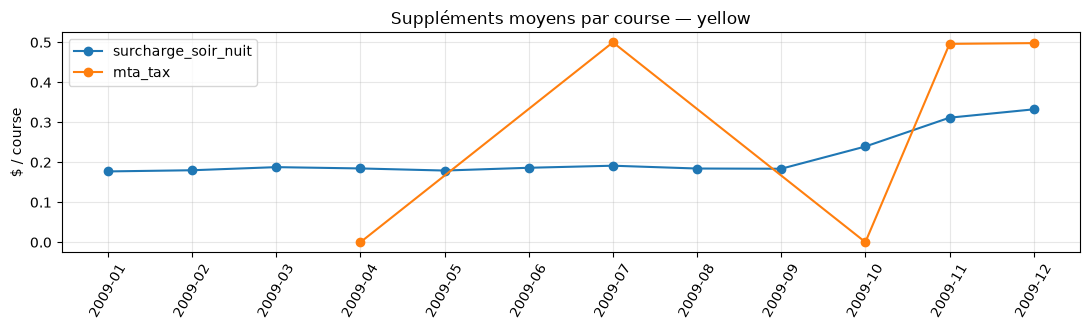

,mois,vtype,surcharge_soir_nuit,mta_tax,amelioration,congestion,aeroport,cbd
0,2009-01,yellow,0.177141,NaN,NaN,NaN,NaN,NaN
1,2009-02,yellow,0.180054,NaN,NaN,NaN,NaN,NaN
2,2009-03,yellow,0.187848,NaN,NaN,NaN,NaN,NaN
3,2009-04,yellow,0.184587,0.000000,NaN,NaN,NaN,NaN
4,2009-05,yellow,0.179321,NaN,NaN,NaN,NaN,NaN
5,2009-06,yellow,0.186250,NaN,NaN,NaN,NaN,NaN
6,2009-07,yellow,0.191409,0.500000,NaN,NaN,NaN,NaN
7,2009-08,yellow,0.184378,NaN,NaN,NaN,NaN,NaN
8,2009-09,yellow,0.183814,NaN,NaN,NaN,NaN,NaN
9,2009-10,yellow,0.239469,0.000242,NaN,NaN,NaN,NaN


In [9]:
# Exercice : Évolution des nouveaux suppléments tarifaires
supplements = spark.sql("""
SELECT date_format(pickup_datetime, 'yyyy-MM') AS mois, vtype,
       avg(extra)                AS surcharge_soir_nuit,
       avg(mta_tax)              AS mta_tax,
       avg(improvement_surcharge) AS amelioration,
       avg(congestion_surcharge)  AS congestion,
       avg(airport_fee)           AS aeroport,
       avg(cbd_convenience_fee)   AS cbd
FROM trips
GROUP BY 1, 2 ORDER BY 1, 2""").toPandas()

import matplotlib.pyplot as plt

vtypes = supplements["vtype"].unique()
fig, axes = plt.subplots(len(vtypes), 1, figsize=(11, 3.4 * len(vtypes)), squeeze=False)
for ax, vt in zip(axes[:, 0], vtypes):
    d = supplements[supplements["vtype"] == vt].set_index("mois").drop(columns="vtype", errors="ignore")
    for col in d.columns:
        s = d[col].dropna()
        if len(s):
            ax.plot(s.index, s.values, marker="o", label=col)
    ax.set_title(f"Suppléments moyens par course — {vt}")
    ax.set_ylabel("$ / course")
    ax.grid(alpha=.3)
    ax.legend()
    ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

display(supplements[supplements["vtype"] == "yellow"].head(14))

C:\Users\soufp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


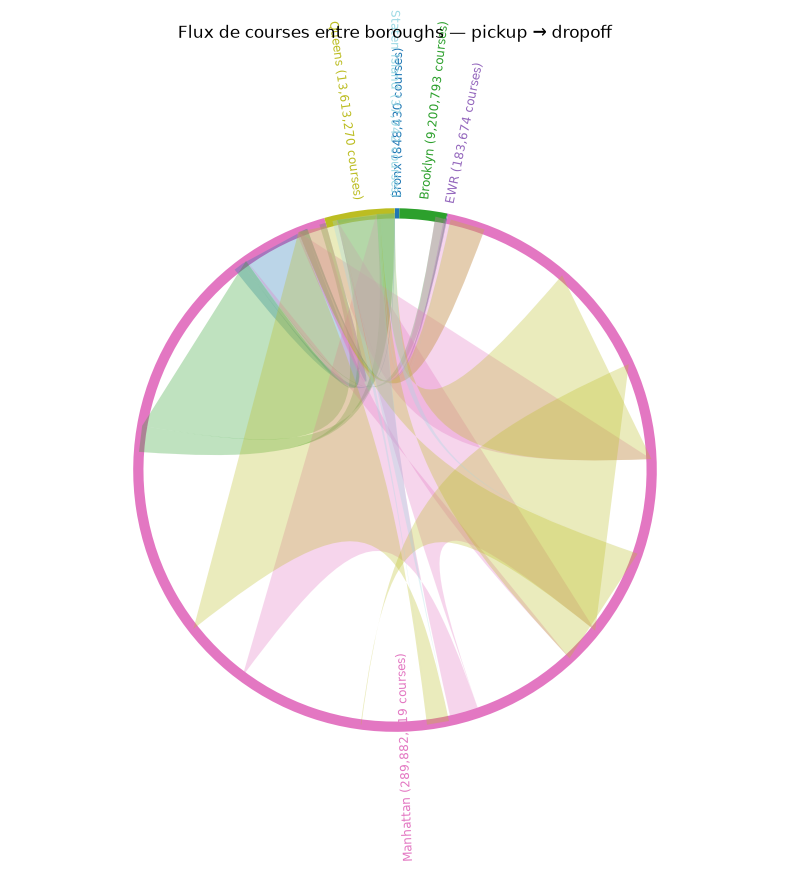

arrivee         Bronx  Brooklyn     EWR  Manhattan   Queens  Staten Island
depart                                                                    
Bronx           49403      1186      52      37708     5067             12
Brooklyn         4897   1196656    1318    1138256   148737           1358
EWR                 6        28       0        258       64             13
Manhattan      590099   4792179  177876  136918283  5271844          22990
Queens         110582    719177    4034    4013805  1666571           6654
Staten Island      15       345      25        938      164           2714


In [10]:
# Exercice : Diagramme en corde des flux pickup/dropoff
flows = spark.sql("""
SELECT zb.borough AS depart, zd.borough AS arrivee, count(*) AS courses
FROM trips t
JOIN zones zb ON t.pickup_location_id = zb.location_id
JOIN zones zd ON t.dropoff_location_id = zd.location_id
WHERE t.pickup_location_id <> t.dropoff_location_id
GROUP BY 1, 2""").toPandas()

labels = sorted(set(flows["depart"]) | set(flows["arrivee"]))
mat = (flows.pivot(index="depart", columns="arrivee", values="courses")
       .reindex(index=labels, columns=labels).fillna(0.0))

import numpy as np
from matplotlib.patches import PathPatch, Wedge
from matplotlib.path import Path

def chord_diagram(mat, title="", unit="courses"):
    labels = list(mat.index)
    n = len(labels)
    flows_v = mat.values.astype(float)
    node_size = flows_v.sum(axis=1) + flows_v.sum(axis=0)
    colors = plt.cm.tab20(np.linspace(0, 1, max(n, 2)))

    fracs = node_size / node_size.sum()
    sect, a = [], 90.0                       # départ à midi, sens horaire
    for f in fracs:
        span = 360.0 * f
        sect.append((a - span, a))
        a -= span

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.set_aspect("equal"); ax.axis("off")

    def pt(angle_deg, r=1.0):
        t = np.deg2rad(angle_deg)
        return r * np.cos(t), r * np.sin(t)

    for k, ((a0, a1), lab) in enumerate(zip(sect, labels)):
        ax.add_patch(Wedge((0, 0), 1.02, a0, a1, width=0.04,
                           facecolor=colors[k], edgecolor="none"))
        mid_deg = (a0 + a1) / 2
        mid = np.deg2rad(mid_deg)
        etiquette = f"{lab} ({node_size[k]:,.0f} {unit})"
        if a1 - a0 < 25:                       # secteur étroit => étiquette radiale
            m = mid_deg % 360
            if 90 < m < 270:
                rot, ha = mid_deg + 180, "right"
            else:
                rot, ha = mid_deg, "left"
            ax.text(1.06 * np.cos(mid), 1.06 * np.sin(mid), etiquette,
                    ha=ha, va="center", rotation=rot, rotation_mode="anchor",
                    fontsize=8.5, color=colors[k])
        else:                                  # gros secteur => étiquette tangentielle
            rot = mid_deg if 0 <= (mid_deg % 360) <= 180 else mid_deg + 180
            ax.text(1.12 * np.cos(mid), 1.12 * np.sin(mid), etiquette,
                    ha="center", va="center", rotation=rot, rotation_mode="anchor",
                    fontsize=8.5, color=colors[k])

    out_cur = {k: sect[k][0] for k in range(n)}
    in_cur = {k: sect[k][0] for k in range(n)}
    K = 0.15                                  # tirage des béziers vers le centre
    for i in range(n):
        for j in range(n):
            v = flows_v[i, j]
            if v <= 0:
                continue
            i0, i1 = out_cur[i], out_cur[i] + 360.0 * v / node_size[i]; out_cur[i] = i1
            j0, j1 = in_cur[j], in_cur[j] + 360.0 * v / node_size[j]; in_cur[j] = j1
            if i == j:
                continue                      # flux internes : consommés mais non dessinés
            e0a, e0b, e1a, e1b = pt(i0), pt(i1), pt(j0), pt(j1)
            verts = [e0a,
                     (K * e0a[0], K * e0a[1]), (K * e1a[0], K * e1a[1]), e1a,
                     e1b,
                     (K * e1b[0], K * e1b[1]), (K * e0b[0], K * e0b[1]), e0b,
                     e0a]
            codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
                     Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY]
            ax.add_patch(PathPatch(Path(verts, codes),
                                   facecolor=colors[i], alpha=0.30, edgecolor="none"))
    ax.set_title(title, pad=34)
    return ax

chord_diagram(mat, title="Flux de courses entre boroughs — pickup → dropoff")
plt.show()

print(mat.astype(int).to_string())

+-------------------------+-------+
|zone_name                |c      |
+-------------------------+-------+
|Midtown Center           |6393195|
|Times Sq/Theatre District|5952545|
|Upper East Side South    |5872339|
|East Village             |5610192|
|Upper East Side North    |5460891|
+-------------------------+-------+



C:\Users\soufp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


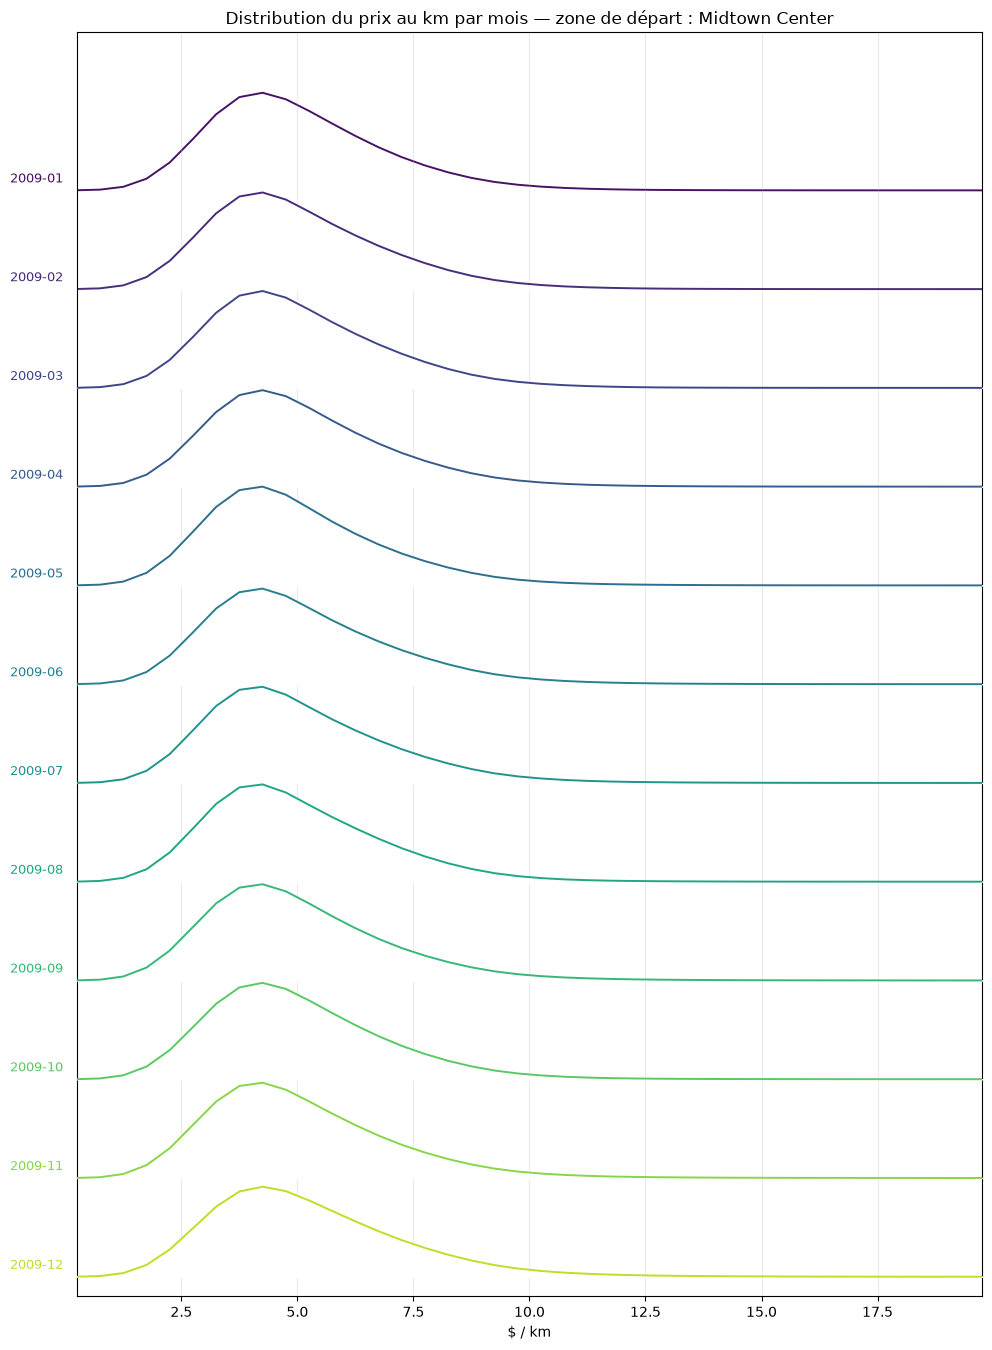

In [11]:
# Exercice : Ridgeline plot de l'évolution du prix par zone de départ
ZONE_DEPART = None   # ex. "Upper East Side South" ; None => zone la plus fréquente

top_zones = spark.sql("""
SELECT z.zone_name, count(*) AS c
FROM trips t JOIN zones z ON t.pickup_location_id = z.location_id
WHERE t.trip_distance BETWEEN 0.5 AND 50 AND t.fare_amount > 2.5
GROUP BY 1 ORDER BY c DESC LIMIT 5""")
top_zones.show(5, False)

zone_name = ZONE_DEPART or top_zones.first()["zone_name"]
loc_id = spark.read.parquet(str(SILVER / "ref" / "zones.parquet")).where(
    F.col("zone_name") == zone_name).first()["location_id"]

period_fmt = "yyyy-MM" if spark.sql("SELECT count(DISTINCT year) AS n FROM trips").first()["n"] == 1 else "yyyy"

hist = spark.sql(f"""
WITH base AS (
    SELECT date_format(pickup_datetime, '{period_fmt}') AS periode,
           fare_amount / trip_distance AS prix_km
    FROM trips
    WHERE pickup_location_id = {int(loc_id)}
      AND trip_distance BETWEEN 0.5 AND 50 AND fare_amount > 2.5 AND fare_amount / trip_distance < 20
)
SELECT periode, cast(floor(prix_km / 0.5) AS int) AS bin, count(*) AS n
FROM base GROUP BY 1, 2""").toPandas()

BIN_W = 0.5
xs = np.arange(hist["bin"].min(), hist["bin"].max() + 1) * BIN_W + BIN_W / 2
curves = {}
for periode, grp in hist.groupby("periode"):
    dens = np.zeros(len(xs))
    for _, r in grp.iterrows():
        idx = int(round((r["bin"] * BIN_W + BIN_W / 2 - xs[0]) / BIN_W))
        if 0 <= idx < len(dens):
            dens[idx] += r["n"]
    total = dens.sum()
    dens = dens / (total * BIN_W) if total else dens
    kern = np.array([1, 4, 6, 4, 1]) / 16.0
    dens = np.convolve(np.convolve(dens, kern, "same"), kern, "same")
    curves[periode] = dens

order = sorted(curves)
fig, ax = plt.subplots(figsize=(10, 1.0 * len(order) + 1.6))
palette = plt.cm.viridis(np.linspace(0.05, 0.9, len(order)))
ymax = max(c.max() for c in curves.values())
for k, periode in enumerate(order):
    base = 1.0 * (len(order) - 1 - k)
    y = curves[periode] / ymax
    ax.fill_between(xs, base, base + y, color="white", zorder=k + 1)
    ax.plot(xs, base + y, color=palette[k], lw=1.4, zorder=k + 1)
    ax.text(xs[0] - 0.3, base + 0.08, periode, ha="right", fontsize=9, color=palette[k])
ax.set_xlim(xs[0], xs[-1]); ax.set_ylim(-0.2, len(order) + 0.6)
ax.set_yticks([])
ax.set_xlabel("$ / km"); ax.grid(alpha=.25, axis="x")
ax.set_title(f"Distribution du prix au km par {'année' if period_fmt == 'yyyy' else 'mois'} "
             f"— zone de départ : {zone_name}")
plt.tight_layout(); plt.show()

C:\Users\soufp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


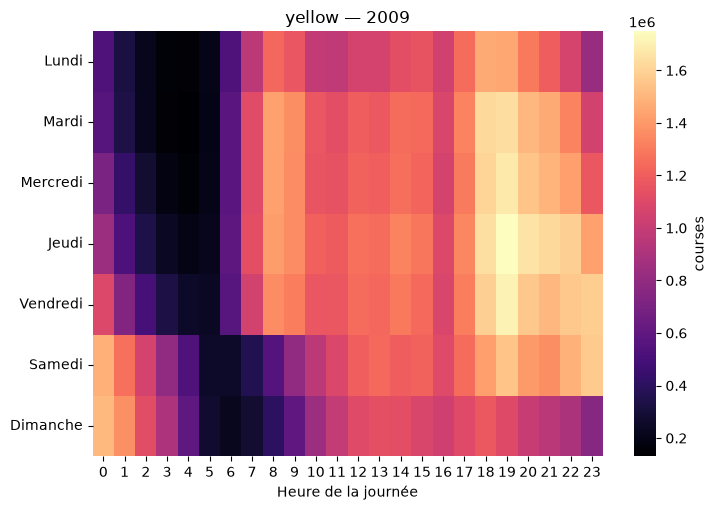

In [12]:
# Exercice : Fonction heatmap(annee) : fréquence des courses par jour/heure et par type de véhicule
import seaborn as sns

JOURS = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]

def heatmap_annee(annee):
    dfh = spark.sql(f"""
    SELECT vtype,
           pmod(dayofweek(pickup_datetime) + 5, 7) AS jour,   -- 0=Lundi ... 6=Dimanche
           hour(pickup_datetime) AS heure,
           count(*) AS courses
    FROM trips
    WHERE year = {annee}
    GROUP BY 1, 2, 3""").toPandas()

    vtypes = sorted(dfh["vtype"].unique())
    fig, axes = plt.subplots(1, len(vtypes), figsize=(7.5 * len(vtypes), 5.2), squeeze=False)
    for ax, vt in zip(axes[0], vtypes):
        piv = (dfh[dfh["vtype"] == vt]
               .pivot(index="jour", columns="heure", values="courses")
               .reindex(index=range(7)).fillna(0))
        sns.heatmap(piv, ax=ax, cmap="magma", cbar_kws={"label": "courses"})
        ax.set_title(f"{vt} — {annee}")
        ax.set_yticklabels(JOURS, rotation=0)
        ax.set_xlabel("Heure de la journée")
        ax.set_ylabel("")
    plt.tight_layout(); plt.show()

heatmap_annee(2009)

C:\Users\soufp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


conditions   courses  prix_km_moyen  ecart_pct
       sec 142689004       4.598657  -0.254991
     pluie  19457448       4.696955   1.877108

Prix moyen global : 4.610 $/km (162,141,695 courses)


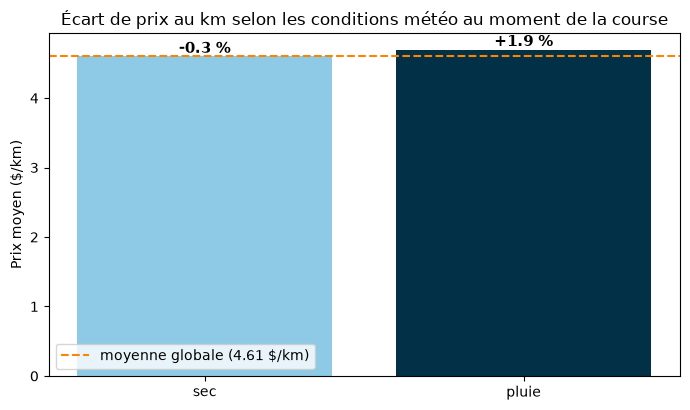

In [13]:
# Exercice : Écart de prix selon la météo (prix/km sous la pluie vs au sec vs moyenne générale)
meteo_prix = spark.sql("""
SELECT /*+ BROADCAST(w) */
       CASE WHEN w.precipitation_mm > 0.2 THEN 'pluie' ELSE 'sec' END AS conditions,
       count(*) AS courses,
       avg(t.fare_amount / t.trip_distance) AS prix_km_moyen
FROM trips t
JOIN weather_hourly w ON date_trunc('hour', t.pickup_datetime) = w.ts
WHERE t.trip_distance BETWEEN 0.5 AND 50 AND t.fare_amount > 2.5
GROUP BY 1""").toPandas()

overall = spark.sql("""
SELECT avg(fare_amount / trip_distance) AS m, count(*) AS n
FROM trips WHERE trip_distance BETWEEN 0.5 AND 50 AND fare_amount > 2.5""").first()
moyenne_globale = overall["m"]

meteo_prix["ecart_pct"] = 100 * (meteo_prix["prix_km_moyen"] / moyenne_globale - 1)
print(meteo_prix.to_string(index=False))
print(f"\nPrix moyen global : {moyenne_globale:.3f} $/km ({overall['n']:,} courses)")

fig, ax = plt.subplots(figsize=(7, 4.2))
colors = {"sec": "#8ecae6", "pluie": "#023047"}
bars = ax.bar(meteo_prix["conditions"], meteo_prix["prix_km_moyen"],
              color=[colors.get(c, "gray") for c in meteo_prix["conditions"]])
ax.axhline(moyenne_globale, color="#fb8500", ls="--", lw=1.5,
           label=f"moyenne globale ({moyenne_globale:.2f} $/km)")
for b, ecart in zip(bars, meteo_prix["ecart_pct"]):
    ax.annotate(f"{ecart:+.1f} %", (b.get_x() + b.get_width() / 2, b.get_height()),
                ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Prix moyen ($/km)")
ax.set_title("Écart de prix au km selon les conditions météo au moment de la course")
ax.legend()
plt.tight_layout(); plt.show()